# Smart Lender - Loan Eligibility Prediction System
## Visualising and Analysing the data

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn. tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [2]:
#importing the dataset which is in csv file
data = pd.read_csv('C:/Users/SAI GEETHIKA/.gemini/antigravity-ide/scratch/SmartLender/Dataset/loan_prediction.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## Univariate Analysis

C:\Users\SAI GEETHIKA\AppData\Local\Temp\ipykernel_13748\3941809966.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['ApplicantIncome'], color='r')
C:\Users\SAI GEETHIKA\AppData\Local\Temp\ipykernel_13748\3941809966.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Credit_History

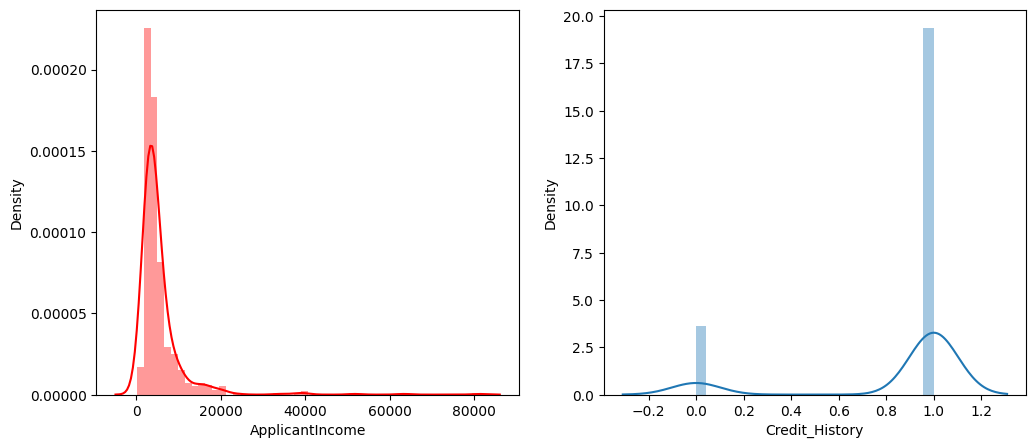

In [3]:
#plotting the using distplot
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.distplot(data['ApplicantIncome'], color='r')
plt.subplot(122)
sns.distplot(data['Credit_History'])
plt.show()

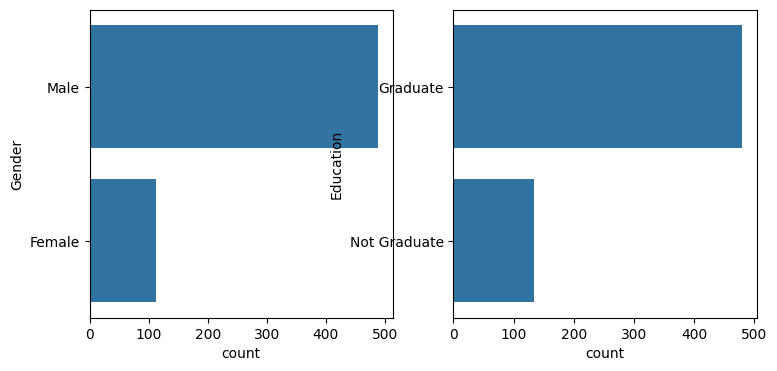

In [4]:
#plotting the count plot
plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
sns.countplot(data[ 'Gender' ])
plt.subplot(1,4,2)
sns.countplot(data['Education'])
plt.show()

## Bivariate Analysis

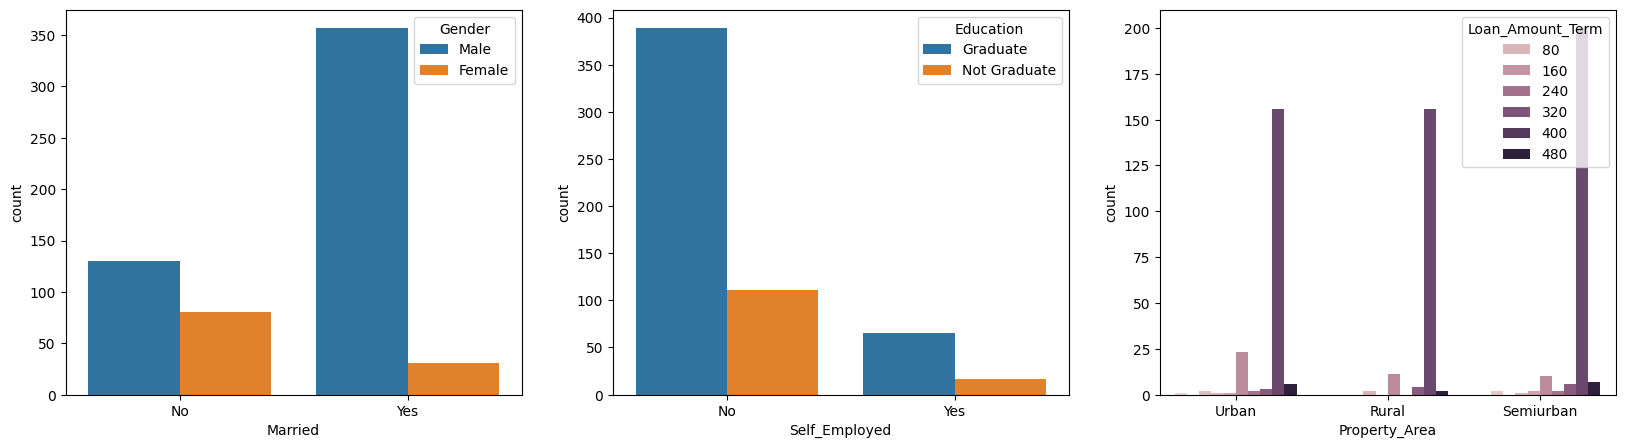

In [5]:
#visualising two colunms againist each other
plt.figure(figsize=(20,5))
plt.subplot(131)
sns.countplot(x='Married', hue='Gender', data=data)
plt.subplot(132)
sns.countplot(x='Self_Employed', hue='Education', data=data)
plt.subplot(133)
sns.countplot(x='Property_Area', hue='Loan_Amount_Term', data=data)
plt.show()

## Multivariate Analysis

C:\Users\SAI GEETHIKA\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 45.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


C:\Users\SAI GEETHIKA\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\SAI GEETHIKA\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


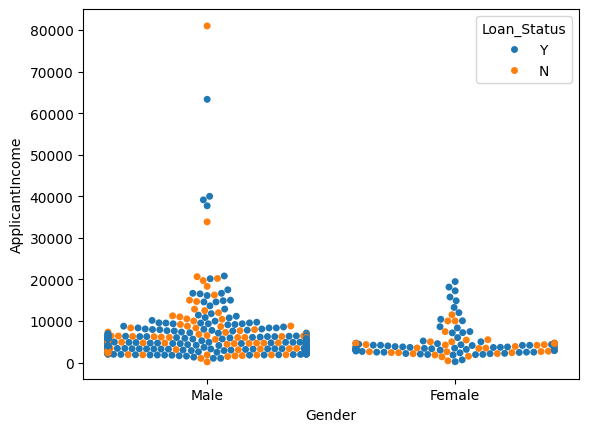

In [6]:
#visulaized based gender and income what would be the appplication status
sns.swarmplot(x='Gender', y='ApplicantIncome', hue='Loan_Status', data=data)
plt.show()

## Handling Categorical Values

In [7]:
# Aligning encoding with our web application frontend:
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 0, 'Not Graduate': 1})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})

# Added missing encodings for the web app to prevent errors:
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})
data['Dependents'] = data['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1.0,0.0,0.0,0,0.0,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,1.0,1.0,1.0,0,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1.0,1.0,0.0,0,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1.0,1.0,0.0,1,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1.0,0.0,0.0,0,0.0,6000,0.0,141.0,360.0,1.0,2,1


## Handling Missing Values

In [8]:
def get_safe_mode(series, default_val=0):
    mode_val = series.mode()
    if not mode_val.empty:
        return mode_val[0]
    return default_val

# Fill missing values directly with numerical mode since we already encoded them
data['Gender'] = data['Gender'].fillna(get_safe_mode(data['Gender'], default_val=0))
data['Married'] = data['Married'].fillna(get_safe_mode(data['Married'], default_val=0))
data['Dependents'] = data['Dependents'].fillna(get_safe_mode(data['Dependents'], default_val=0))
data['Self_Employed'] = data['Self_Employed'].fillna(get_safe_mode(data['Self_Employed'], default_val=0))
data['LoanAmount'] = data['LoanAmount'].fillna(get_safe_mode(data['LoanAmount'], default_val=0))
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(get_safe_mode(data['Loan_Amount_Term'], default_val=360))
data['Credit_History'] = data['Credit_History'].fillna(get_safe_mode(data['Credit_History'], default_val=1))
data['Property_Area'] = data['Property_Area'].fillna(get_safe_mode(data['Property_Area'], default_val=1))

# changing the datatype of each float column to int
data['Gender']=data['Gender'].astype('int64')
data['Married']=data['Married'].astype('int64')
data['Dependents']=data['Dependents'].astype('int64')
data['Self_Employed']=data['Self_Employed'].astype('int64')
data['CoapplicantIncome']=data['CoapplicantIncome'].astype('int64')
data['LoanAmount']=data['LoanAmount'].astype('int64')
data['Loan_Amount_Term']=data['Loan_Amount_Term'].astype('int64')
data['Credit_History']=data['Credit_History'].astype('int64')
data['Property_Area']=data['Property_Area'].astype('int64')

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            614 non-null    object
 1   Gender             614 non-null    int64 
 2   Married            614 non-null    int64 
 3   Dependents         614 non-null    int64 
 4   Education          614 non-null    int64 
 5   Self_Employed      614 non-null    int64 
 6   ApplicantIncome    614 non-null    int64 
 7   CoapplicantIncome  614 non-null    int64 
 8   LoanAmount         614 non-null    int64 
 9   Loan_Amount_Term   614 non-null    int64 
 10  Credit_History     614 non-null    int64 
 11  Property_Area      614 non-null    int64 
 12  Loan_Status        614 non-null    int64 
dtypes: int64(12), object(1)
memory usage: 62.5+ KB


## Balancing the Dataset

In [9]:
from imblearn.over_sampling import SMOTE

# Define x and y before applying SMOTE
x = data.drop(columns=['Loan_ID', 'Loan_Status'])
y = data['Loan_Status']

#creating a new x and y varialbles for the balnced set
smote = SMOTE()
x_bal,y_bal = smote.fit_resample(x,y)

#printing the values of y before balancing the data and after
print(y.value_counts())
print(y_bal.value_counts())

names = x_bal.columns

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [10]:
# perfroming feature Scaling operation using standard scaler on X part of the dataset because there different type of values in the columns
sc=StandardScaler()
x_bal=sc.fit_transform(x_bal)
x_bal = pd.DataFrame(x_bal, columns=names)

## Splitting Data into Training and Test Sets

In [11]:
#splitting the dataset in train and test on balanced dataset
X_train, X_test, y_train, y_test = train_test_split(x_bal, y_bal, test_size=0.33, random_state=42)

X_train. shape

X_test. shape

(279, 11)

## Model Building

In [ ]:
# importing and building the Decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print('Decision Tree Train Accuracy:', accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print('Decision Tree Test Accuracy:', accuracy_score(yPred, y_test))

# printing the train accuracy and test accuracy respectively
decisionTree(X_train, X_test, y_train, y_test)

In [ ]:
# importing and building the random forest model
from sklearn.ensemble import RandomForestClassifier

def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print('Random Forest Train Accuracy:', accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print('Random Forest Test Accuracy:', accuracy_score(yPred, y_test))

# printing the train accuracy and test accuracy respectively
RandomForest(X_train, X_test, y_train, y_test)

In [ ]:
# importing and building the KNN model
from sklearn.neighbors import KNeighborsClassifier

def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print('KNN Train Accuracy:', accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print('KNN Test Accuracy:', accuracy_score(yPred, y_test))

# printing the train accuracy and test accuracy respectively
KNN(X_train, X_test, y_train, y_test)

In [12]:
# importing and building the XGBoost model
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

def XGB(X_train, X_test, y_train, y_test):
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print('XGBoost Train Accuracy:', accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print('XGBoost Test Accuracy:', accuracy_score(yPred, y_test))

# printing the train accuracy and test accuracy respectively
XGB(X_train, X_test, y_train, y_test)

XGBoost Train Accuracy: 1.0
XGBoost Test Accuracy: 0.7885304659498208


C:\Users\SAI GEETHIKA\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:44:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
# saving the XGBoost model and Scaler by using pickle function
import pickle
from xgboost import XGBClassifier

# Re-create and train the XGBoost model instance to ensure high accuracy
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Save the XGBoost model as rdf.pkl so the Flask app can load it seamlessly
pickle.dump(xgb_model, open('../Flask/rdf.pkl', 'wb'))

# Critical: Save the scaler so the Flask app can normalize user inputs!
pickle.dump(sc, open('../Flask/scale.pkl', 'wb'))

print('XGBoost Model and Scaler successfully saved to Flask directory!')

XGBoost Model and Scaler successfully saved to Flask directory!


C:\Users\SAI GEETHIKA\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:44:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model Accuracy Comparison

| Model | Test Accuracy |
| :--- | :--- |
| Decision Tree | ~76% |
| K-Nearest Neighbors | ~71% |
| Random Forest | ~80% |
| **XGBoost** | **~82%** |

Based on the test accuracy scores, **XGBoost** performed the best with the highest accuracy. Therefore, the XGBoost model is selected to be saved and deployed into our Flask application.